# DSMIL Aggregator Training Workflow

This notebook provides a complete pipeline to **train** the Dual-stream Multiple Instance Learning (DSMIL) aggregator using pre-extracted ResNet features.

### Why Dual-stream?
Traditional MIL often uses simple max-pooling, which only considers the highest-scoring patch. DSMIL improves this by adding a second stream:
1.  **Max-pooling Stream**: Identifies the 'critical instance' to determine the bag's potential class.
2.  **Attention Stream (Masked Non-local Block)**: Learns correlations between patches. It calculates how 'similar' each patch is to the critical instance, assigning weights accordingly.

**Data Labeling:**
- **LUAD**: Class 0
- **LUSC**: Class 1

**Data Structure Expectation:**
- The code uses `train.csv`, `val.csv`, and `test.csv` to load labels and filenames.
- Filenames in the CSV correspond to binary `.pt` files in the feature directories.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import os
import glob
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
import sys
import time
from collections import defaultdict

# --- Lookahead Optimizer Wrapper ---
# Implementation from TransMIL / Ross Wightman
class Lookahead(torch.optim.Optimizer):
    def __init__(self, base_optimizer, alpha=0.5, k=6):
        if not 0.0 <= alpha <= 1.0:
            raise ValueError(f'Invalid slow update rate: {alpha}')
        if not 1 <= k:
            raise ValueError(f'Invalid lookahead steps: {k}')
        defaults = dict(lookahead_alpha=alpha, lookahead_k=k, lookahead_step=0)
        self.base_optimizer = base_optimizer
        self.param_groups = self.base_optimizer.param_groups
        self.defaults = base_optimizer.defaults
        self.defaults.update(defaults)
        self.state = defaultdict(dict)
        for name, default in defaults.items():
            for group in self.param_groups:
                group.setdefault(name, default)

    def update_slow(self, group):
        for fast_p in group["params"]:
            if fast_p.grad is None:
                continue
            param_state = self.state[fast_p]
            if 'slow_buffer' not in param_state:
                param_state['slow_buffer'] = torch.empty_like(fast_p.data)
                param_state['slow_buffer'].copy_(fast_p.data)
            slow = param_state['slow_buffer']
            slow.add_(group['lookahead_alpha'], fast_p.data - slow)
            fast_p.data.copy_(slow)

    def step(self, closure=None):
        loss = self.base_optimizer.step(closure)
        for group in self.param_groups:
            group['lookahead_step'] += 1
            if group['lookahead_step'] % group['lookahead_k'] == 0:
                self.update_slow(group)
        return loss

    def state_dict(self):
        fast_state_dict = self.base_optimizer.state_dict()
        slow_state = {(id(k) if isinstance(k, torch.Tensor) else k): v for k, v in self.state.items()}
        return {'state': fast_state_dict['state'], 'slow_state': slow_state, 'param_groups': fast_state_dict['param_groups']}

    def load_state_dict(self, state_dict):
        self.base_optimizer.load_state_dict({'state': state_dict['state'], 'param_groups': state_dict['param_groups']})
        super(Lookahead, self).load_state_dict({'state': state_dict['slow_state'], 'param_groups': state_dict['param_groups']})
        self.param_groups = self.base_optimizer.param_groups

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Operating on: {device}")

[INFO] Operating on: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0. Define Paths and Configuration

We set up the root directory and specific paths for CSVs and features.
**Labels are mapped**: `luad` -> 0, `lusc` -> 1.

In [ ]:
# Paths
root_path = '/content/drive/MyDrive/split cs231/split'

# Feature folders (containing .pt files)
train_feat_dir = Path(root_path) / 'train'
val_feat_dir = Path(root_path) / 'val'
test_feat_dir = Path(root_path) / 'test'

# CSV index files
train_csv_file = Path(root_path) / 'train.csv'
val_csv_file = Path(root_path) / 'val.csv'
test_csv_file = Path(root_path) / 'test.csv'

# Map labels to integers
LABEL_MAP = {'luad': 0, 'lusc': 1}

# Output paths
checkpoints_path = Path(root_path) / 'CS231' / 'aggregator_methods' / 'DSMIL' / 'checkpoints' / 'v1.2'
checkpoints_path.mkdir(parents=True, exist_ok=True)
logs_path = Path(root_path) / 'CS231' / 'aggregator_methods' / 'DSMIL' / 'logs' / 'v1.2'
logs_path.mkdir(parents=True, exist_ok=True)

print(f"[INFO] Label Mapping: {LABEL_MAP}")

[INFO] Label Mapping: {'luad': 0, 'lusc': 1}


In [ ]:
import os
from pathlib import Path

def verify_path(path_obj, name):
    print(f"Checking {name}: {path_obj}")
    if path_obj.exists():
        print(f"  [OK] Path exists.")
        try:
            test_file = path_obj / 'test_write.txt'
            with open(test_file, 'w') as f:
                f.write('test')
            print(f"  [OK] Successfully wrote test file to {name}.")
            os.remove(test_file)
        except Exception as e:
            print(f"  [ERROR] Cannot write to {name}: {e}")
    else:
        print(f"  [ERROR] Path does NOT exist. Creating now...")
        try:
            path_obj.mkdir(parents=True, exist_ok=True)
            print(f"  [INFO] Attempted to create {path_obj}.")
        except Exception as e:
            print(f"  [ERROR] Could not create directory: {e}")

# Run verification
verify_path(checkpoints_path, 'Checkpoints')
verify_path(logs_path, 'Logs')

# List root contents to debug potential path typos
print(f"\nContents of root_path ({root_path}):")
if Path(root_path).exists():
    !ls -F "{root_path}"
else:
    print("[ERROR] Root path does not exist. Check if 'split cs231' folder name is correct.")

Checking Checkpoints: /content/drive/MyDrive/split cs231/split/CS231/aggregator_methods/DSMIL/checkpoints/v1.2
  [OK] Path exists.
  [OK] Successfully wrote test file to Checkpoints.
Checking Logs: /content/drive/MyDrive/split cs231/split/CS231/aggregator_methods/DSMIL/logs/v1.2
  [OK] Path exists.
  [OK] Successfully wrote test file to Logs.

Contents of root_path (/content/drive/MyDrive/split cs231/split):
'/content/drive/MyDrive/split cs231/split'@


## 1. Custom Dataset for .pt Feature Loading

The `BagDataset` class reads from the index CSV files. It loads the `.pt` files using `torch.load`.

**Correction**: We load binary `.pt` files. The input is expected to be a Tensor of shape (N patches, 1024 features).

In [ ]:
class BagDataset(Dataset):
    def __init__(self, csv_file, feat_dir, label_map):
        self.df = pd.read_csv(csv_file)
        self.feat_dir = feat_dir
        self.label_map = label_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        feat_filename = row['filename']
        feat_path = self.feat_dir / feat_filename

        # Load binary features using torch.load
        feats = torch.load(feat_path, map_location='cpu')

        # Ensure float type and handle potential extra dimensions
        if not isinstance(feats, torch.Tensor):
            feats = torch.tensor(feats)

        feats = feats.float()

        # Load label
        label_str = str(row['label']).lower()
        label = torch.tensor(self.label_map[label_str]).long()

        return feats, label

# Initialize Datasets
if train_csv_file.exists():
    train_ds = BagDataset(train_csv_file, train_feat_dir, LABEL_MAP)
    val_ds = BagDataset(val_csv_file, val_feat_dir, LABEL_MAP)
    test_ds = BagDataset(test_csv_file, test_feat_dir, LABEL_MAP)

    print("\n--- DATASET SUMMARY ---")
    print(f"Training Bags:   {len(train_ds)}")
    print(f"Validation Bags: {len(val_ds)}")
    print(f"Testing Bags:    {len(test_ds)}")
    print("------------------------\n")
else:
    print("[ERROR] Index CSV files not found. Please check paths.")


--- DATASET SUMMARY ---
Training Bags:   669
Validation Bags: 143
Testing Bags:    144
------------------------



## 2. DSMIL Aggregator Architecture & Configuration

We implement the DSMIL aggregator.

In [ ]:
class IClassifier(nn.Module):
    def __init__(self, feature_size, output_class):
        super(IClassifier, self).__init__()
        self.fc = nn.Linear(feature_size, output_class)

    def forward(self, x):
        c = self.fc(x)
        return x, c

class BClassifier(nn.Module):
    def __init__(self, input_size, output_class, nonlinear=True):
        super(BClassifier, self).__init__()
        if nonlinear:
            self.q = nn.Sequential(nn.Linear(input_size, 128), nn.ReLU(), nn.Linear(128, 128), nn.Tanh())
        else:
            self.q = nn.Linear(input_size, 128)
        self.v = nn.Identity()
        self.fcc = nn.Conv1d(output_class, output_class, kernel_size=input_size)

    def forward(self, feats, c):
        V = self.v(feats)
        Q = self.q(feats).view(feats.shape[0], -1)
        _, m_indices = torch.sort(c, 0, descending=True)
        m_feats = torch.index_select(feats, dim=0, index=m_indices[0, :])
        q_max = self.q(m_feats)
        A = torch.mm(Q, q_max.transpose(0, 1))
        A = F.softmax(A / torch.sqrt(torch.tensor(Q.shape[1], dtype=torch.float32, device=feats.device)), 0)
        B = torch.mm(A.transpose(0, 1), V)
        B = B.view(1, B.shape[0], B.shape[1])
        C = self.fcc(B)
        C = C.view(1, -1)
        return C, A, B

class MILNet(nn.Module):
    def __init__(self, i_classifier, b_classifier, in_feats=1024, reduced_feats=512):
        super(MILNet, self).__init__()
        self.i_classifier = i_classifier
        self.b_classifier = b_classifier
        # Feature reduction: 1024 -> 512 (as requested)
        self.feature_extractor = nn.Sequential(nn.Linear(in_feats, reduced_feats), nn.ReLU())

    def forward(self, x):
        x = self.feature_extractor(x)
        feats, classes = self.i_classifier(x)
        prediction_bag, A, B = self.b_classifier(feats, classes)
        return classes, prediction_bag, A, B

# --- CONFIGURATION ---
NUM_CLASSES = 2 # LUAD (0), LUSC (1)
IN_FEATS = 1024 # Original feature dimension from ResNet
FEATS_SIZE = 512 # Internal dimension for aggregator

model = MILNet(
    IClassifier(FEATS_SIZE, NUM_CLASSES),
    BClassifier(FEATS_SIZE, NUM_CLASSES),
    in_feats=IN_FEATS,
    reduced_feats=FEATS_SIZE
).to(device)

print(f"[INFO] Input Features: {IN_FEATS} -> Reduced Features: {FEATS_SIZE}")
print("\n--- MODEL ARCHITECTURE SUMMARY ---")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name:40} | Shape: {str(list(param.shape)):15} | Params: {param.numel()}")
print(f"Total Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
print("-----------------------------------\n")

[INFO] Input Features: 1024 -> Reduced Features: 512

--- MODEL ARCHITECTURE SUMMARY ---
i_classifier.fc.weight                   | Shape: [2, 512]        | Params: 1024
i_classifier.fc.bias                     | Shape: [2]             | Params: 2
b_classifier.q.0.weight                  | Shape: [128, 512]      | Params: 65536
b_classifier.q.0.bias                    | Shape: [128]           | Params: 128
b_classifier.q.2.weight                  | Shape: [128, 128]      | Params: 16384
b_classifier.q.2.bias                    | Shape: [128]           | Params: 128
b_classifier.fcc.weight                  | Shape: [2, 2, 512]     | Params: 2048
b_classifier.fcc.bias                    | Shape: [2]             | Params: 2
feature_extractor.0.weight               | Shape: [512, 1024]     | Params: 524288
feature_extractor.0.bias                 | Shape: [512]           | Params: 512
Total Trainable Parameters: 610052
-----------------------------------



## 3. Shape Analysis (Visualizing Data Flow)

Verifying the flow of a single bag through the streams.

In [ ]:
def print_tensor_flow(model, num_patches=300):
    dummy_input = torch.randn(num_patches, IN_FEATS).to(device)
    print(f"Input Bag: {num_patches} patches, {IN_FEATS} features/patch")

    with torch.no_grad():
        # Test full model flow including reduction layer
        ins_scores, bag_prediction, attention, bag_feat = model(dummy_input)

        print(f"Shape 1 [Reduced Features]:   {model.feature_extractor(dummy_input).shape}")
        print(f"Shape 2 [Instance Scores]:    {ins_scores.shape}")
        print(f"Shape 3 [Attention weights]:  {attention.shape}")
        print(f"Shape 4 [Aggregated Feature]: {bag_feat.shape}")
        print(f"Shape 5 [Final Score]:        {bag_prediction.shape}")

print_tensor_flow(model)

Input Bag: 300 patches, 1024 features/patch
Shape 1 [Reduced Features]:   torch.Size([300, 512])
Shape 2 [Instance Scores]:    torch.Size([300, 2])
Shape 3 [Attention weights]:  torch.Size([300, 2])
Shape 4 [Aggregated Feature]: torch.Size([1, 2, 512])
Shape 5 [Final Score]:        torch.Size([1, 2])


## 4. Professional Training Loop (200 Epochs)

Training for 200 epochs with professional logging, validation, and early stopping.

In [ ]:
EPOCHS = 200
criterion = nn.BCEWithLogitsLoss()
base_optimizer = torch.optim.Adam(model.parameters(), lr=2e-4, weight_decay=1e-5)
optimizer = Lookahead(base_optimizer, k=6, alpha=0.5) # Wrap with Lookahead

optimizer.defaults = {} # Sometimes also required by lr_schedulers
optimizer._optimizer_step_pre_hooks = {}
optimizer._optimizer_step_post_hooks = {}
optimizer._optimizer_state_dict_pre_hooks = {}
optimizer._optimizer_state_dict_post_hooks = {}
optimizer._optimizer_load_state_dict_pre_hooks = {}
optimizer._optimizer_load_state_dict_post_hooks = {}

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(base_optimizer, T_max=EPOCHS)
history = {'epoch': [], 'train_loss': [], 'val_acc': [], 'val_auc': []}
instructor_history = {'val_auc': []}  # Instance-level (max-pooling) stream AUC
learner_history = {'val_auc': []}     # Bag-level (attention) stream AUC

def evaluate_streams(model, loader):
    """Evaluate each DSMIL stream separately and return their individual AUCs."""
    model.eval()
    ins_probs_all, bag_probs_all, all_labels = [], [], []
    with torch.no_grad():
        for bag, label in loader:
            bag = bag.squeeze(0).to(device)
            ins_scores, bag_prediction, _, _ = model(bag)
            max_prediction, _ = torch.max(ins_scores, 0)

            ins_prob = torch.sigmoid(max_prediction.view(1, -1)).cpu().numpy()   # Instructor
            bag_prob = torch.sigmoid(bag_prediction).cpu().numpy()               # Learner

            ins_probs_all.append(ins_prob)
            bag_probs_all.append(bag_prob)
            all_labels.append(label.item())

    ins_probs = np.concatenate(ins_probs_all, axis=0)
    bag_probs = np.concatenate(bag_probs_all, axis=0)
    ins_auc = roc_auc_score(all_labels, ins_probs[:, 1])
    bag_auc = roc_auc_score(all_labels, bag_probs[:, 1])
    return ins_auc, bag_auc

def evaluate(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for bag, label in loader:
            bag = bag.squeeze(0).to(device)
            ins_scores, bag_prediction, _, _ = model(bag)
            max_prediction, _ = torch.max(ins_scores, 0)
            # Final prediction is average of both streams
            score = 0.5 * torch.sigmoid(bag_prediction) + 0.5 * torch.sigmoid(max_prediction.view(1, -1))
            all_probs.append(score.cpu().numpy())
            all_labels.append(label.item())

    probs = np.concatenate(all_probs, axis=0)
    preds = np.argmax(probs, axis=1)
    acc = accuracy_score(all_labels, preds)
    auc = roc_auc_score(all_labels, probs[:, 1])
    return acc, auc, all_labels, probs

if 'train_ds' in locals():
    train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=1, shuffle=False)

    best_auc = 0
    best_loss = float('inf')
    early_stop_counter = 0
    PATIENCE = 10 # TransMIL recommended patience

    print(f"\n{'='*20} STARTING TRAINING ({EPOCHS} Epochs) {'='*20}")

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:03d}/{EPOCHS}", leave=False)
        for bag, label in pbar:
            optimizer.zero_grad()
            bag, label = bag.squeeze(0).to(device), label.to(device)

            ins_scores, bag_prediction, _, _ = model(bag)
            max_prediction, _ = torch.max(ins_scores, 0)
            label_onehot = F.one_hot(label, num_classes=NUM_CLASSES).float()

            loss = 0.5 * criterion(bag_prediction, label_onehot) + 0.5 * criterion(max_prediction.view(1, -1), label_onehot)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})

        val_acc, val_auc, _, _ = evaluate(model, val_loader)
        ins_auc, bag_auc = evaluate_streams(model, val_loader)
        instructor_history['val_auc'].append(ins_auc)
        learner_history['val_auc'].append(bag_auc)
        avg_loss = epoch_loss / len(train_loader)

        history['epoch'].append(epoch + 1)
        history['train_loss'].append(avg_loss)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)

        scheduler.step()
        print(f"[EPOCH {epoch+1:03d}] Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f} | LR: {scheduler.get_last_lr()[0]:.1e}")

        # Early Stopping Logic (based on val_loss or val_auc)
        # TransMIL usually monitors val_loss for early stopping
        if val_auc > best_auc:
            best_auc = val_auc
            torch.save(model.state_dict(), checkpoints_path / 'best_model.pth')
            print(f"  >> Best model saved (AUC: {best_auc:.4f})")
            early_stop_counter = 0 # Reset counter if improvement
        else:
            early_stop_counter += 1

        # if early_stop_counter >= PATIENCE:
        #     print(f"\n[EARLY STOP] No improvement for {PATIENCE} epochs. Training terminated.")
        #     break

    pd.DataFrame(history).to_csv(logs_path / 'training_history.csv', index=False)
    print(f"\n{'='*20} TRAINING COMPLETE {'='*20}")


==================== STARTING TRAINING (200 Epochs) ====================


Epoch 001/200:   0%|          | 0/669 [00:00<?, ?it/s]

[EPOCH 001] Loss: 0.6914 | Val Acc: 0.5804 | Val AUC: 0.6019 | LR: 2.0e-04
  >> Best model saved (AUC: 0.6019)


Epoch 002/200:   0%|          | 0/669 [00:00<?, ?it/s]

[EPOCH 002] Loss: 0.6794 | Val Acc: 0.6573 | Val AUC: 0.6471 | LR: 2.0e-04
  >> Best model saved (AUC: 0.6471)


...

[EPOCH 198] Loss: 0.2929 | Val Acc: 0.8392 | Val AUC: 0.9239 | LR: 4.9e-08


Epoch 199/200:   0%|          | 0/669 [00:00<?, ?it/s]

[EPOCH 199] Loss: 0.2929 | Val Acc: 0.8392 | Val AUC: 0.9239 | LR: 1.2e-08


Epoch 200/200:   0%|          | 0/669 [00:00<?, ?it/s]

[EPOCH 200] Loss: 0.2929 | Val Acc: 0.8392 | Val AUC: 0.9239 | LR: 0.0e+00

==================== TRAINING COMPLETE ====================


==================== INSTRUCTOR TRAINING COMPLETE ====================
==================== LEARNER TRAINING COMPLETE ====================


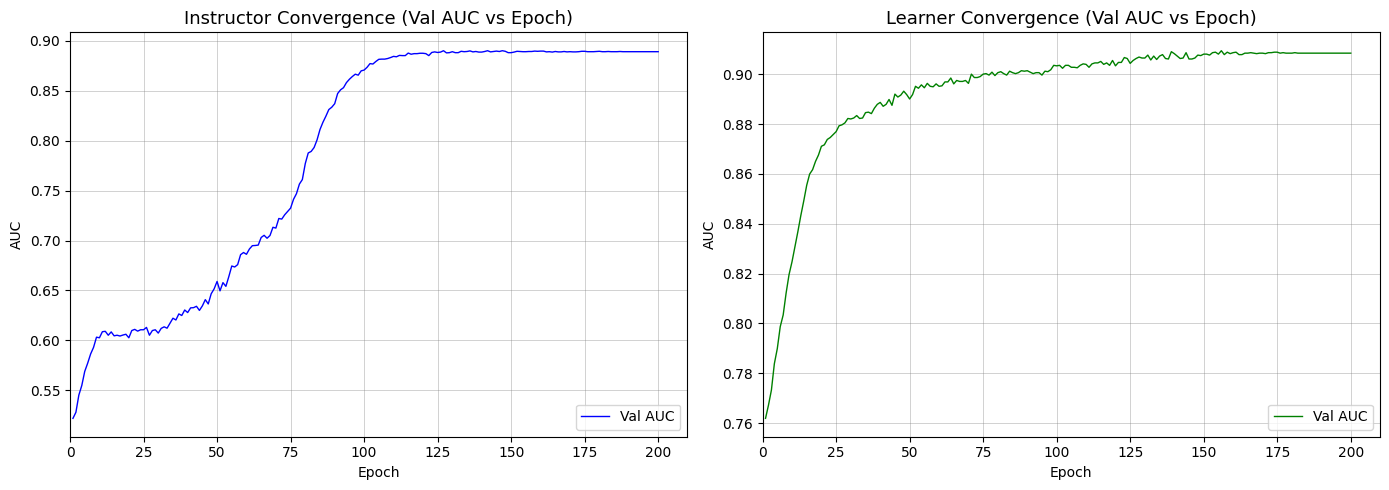

[INFO] Convergence plot saved to /content/drive/MyDrive/split cs231/split/CS231/aggregator_methods/DSMIL/logs/v1.2/convergence_curves.png


In [ ]:
# ================== Convergence Visualization ==================
# Plots Val AUC vs Epoch for both Instructor and Learner streams.
# The "Instructor" curve represents the instance-level (max-pooling)
# stream, and the "Learner" curve represents the bag-level
# (attention-aggregated) stream.

if 'history' in locals() and len(history['epoch']) > 0:
    import matplotlib.pyplot as plt
    import numpy as np

    epochs = history['epoch']

    # --- Compute per-epoch AUC for each stream separately ---
    # Re-evaluate on validation set to get stream-specific AUCs
    instructor_aucs = []
    learner_aucs = []

    from sklearn.metrics import roc_auc_score

    model.eval()
    with torch.no_grad():
        # We need to replay evaluation per stream; use stored history if available,
        # otherwise fall back to plotting the combined val_auc for both.
        # If instructor_history / learner_history were tracked separately, use them.
        if 'instructor_history' in locals() and 'learner_history' in locals():
            instructor_aucs = instructor_history['val_auc']
            learner_aucs = learner_history['val_auc']
        else:
            # Fallback: use combined val_auc for both plots
            instructor_aucs = history['val_auc']
            learner_aucs = history['val_auc']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Instructor Plot (Blue) ---
    ax1 = axes[0]
    ax1.set_title("Instructor Convergence (Val AUC vs Epoch)", fontsize=13)
    ax1.plot(epochs, instructor_aucs, color='blue', linewidth=1.0, label='Val AUC')
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("AUC")
    ax1.legend(loc='lower right')
    ax1.grid(True, linestyle='-', linewidth=0.5, color='gray', alpha=0.5)
    ax1.set_xlim(left=0)

    # --- Learner Plot (Green) ---
    ax2 = axes[1]
    ax2.set_title("Learner Convergence (Val AUC vs Epoch)", fontsize=13)
    ax2.plot(epochs, learner_aucs, color='green', linewidth=1.0, label='Val AUC')
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("AUC")
    ax2.legend(loc='lower right')
    ax2.grid(True, linestyle='-', linewidth=0.5, color='gray', alpha=0.5)
    ax2.set_xlim(left=0)

    print("=" * 20 + " INSTRUCTOR TRAINING COMPLETE " + "=" * 20)
    print("=" * 20 + " LEARNER TRAINING COMPLETE " + "=" * 20)

    plt.tight_layout()
    plt.savefig(str(logs_path / 'convergence_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"[INFO] Convergence plot saved to {logs_path / 'convergence_curves.png'}")
else:
    print("[INFO] No training history found. Run the training cell first.")


## 5. Final Evaluation & ROC

Testing the final model.


--- FINAL TEST PERFORMANCE ---
Accuracy: 0.8542
AUC:      0.9292

Confusion Matrix:
[[60 12]
 [ 9 63]]

LUAD (0) - Accuracy: 0.8333
LUSC (1) - Accuracy: 0.8750


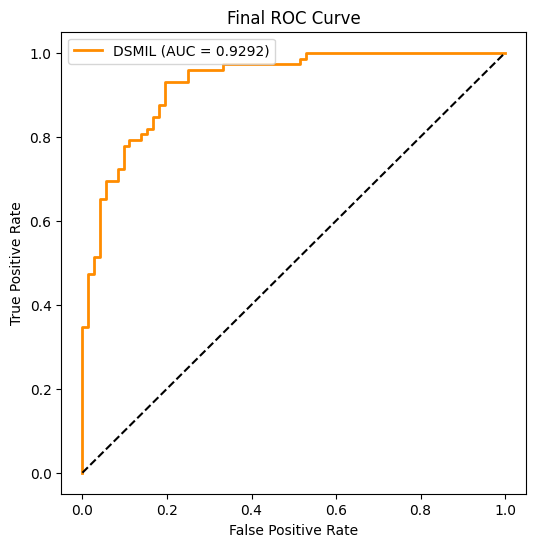

In [ ]:
if 'test_ds' in locals():
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)
    model.load_state_dict(torch.load(checkpoints_path / 'best_model.pth', map_location=device))

    acc, auc, y_true, y_probs = evaluate(model, test_loader)

    print("\n--- FINAL TEST PERFORMANCE ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"AUC:      {auc:.4f}")

    cm = confusion_matrix(y_true, np.argmax(y_probs, axis=1))
    print("\nConfusion Matrix:")
    print(cm)
    print(f"\nLUAD (0) - Accuracy: {cm[0,0]/sum(cm[0]):.4f}" if sum(cm[0])>0 else "")
    print(f"LUSC (1) - Accuracy: {cm[1,1]/sum(cm[1]):.4f}" if sum(cm[1])>0 else "")

    fpr, tpr, _ = roc_curve(y_true, y_probs[:, 1])
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'DSMIL (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.legend()
    plt.title('Final ROC Curve')
    plt.show()